In [1]:
import statistics
import numpy as np
import pandas as pd
import glob
import matplotlib
import matplotlib.pyplot as plt

from pandas import DataFrame
from ast import literal_eval
from ast import literal_eval
from pylab import plot, show, savefig, xlim, figure, ylim, legend, boxplot, setp, axes


In [2]:
num_layers = 3
width_layers = 80 
num_gateways = 80 
total_bins = 1 
log_dir = '/Users/claudia/PycharmProjects/MixMeasurement/Logs_Rel_v3/'

#type_setup = ["Rel90_Error*", "Rel97.2_Error*", "Rel98.9_Error*"]
type_setup = ["40r40u*"]
sample_subset = ["_25k", "_50k", "_100k", "_250k", "_500k", "_1m", "_2m"]


In [3]:
dict_files_nodes = {}
dict_files_links = {}
for setup in type_setup:
    for selected_set in sample_subset: 
        str_file_nodes = log_dir + setup + selected_set + "/*_nodes.csv"
        str_file_links = log_dir + setup + selected_set + "/*_links.csv"
        dict_files_nodes[setup+selected_set] = [f for f in glob.glob(str_file_nodes)]
        dict_files_links[setup+selected_set] = [f for f in glob.glob(str_file_links)]
    

In [4]:
dict_all_nodes = {}
for setup in type_setup:
    for selected_set in sample_subset: 
        for file_name_nodes in dict_files_nodes[setup+selected_set]:
            df_net_nodes = pd.read_csv(str(file_name_nodes))
            dict_read_nodes = df_net_nodes.to_dict()
            dict_net_nodes = {}
            
            for entry in dict_read_nodes['id']:
                dict_net_nodes[dict_read_nodes['id'][entry]] = {}
            for g in range(num_gateways):
                dict_net_nodes[str(g)] = literal_eval(dict_read_nodes[str(0)][g])
            for layer in range(1, num_layers+1):
                for w in range(width_layers): 
                    mix_id = num_gateways + (layer-1)*width_layers + w 
                    dict_net_nodes[str(mix_id)] = literal_eval(dict_read_nodes[str(layer)][mix_id])
            dict_all_nodes[file_name_nodes] = dict_net_nodes
        

In [5]:
error_all = {}
error_reliable = {}
error_unreliable = {}
sampling_error_all = {}
sampling_error_reliable = {}
sampling_error_unreliable = {}
beta_error_all = {}
beta_error_reliable = {}
beta_error_unreliable = {}


for setup in type_setup:
    for selected_set in sample_subset: 
        error_all[setup+selected_set] = []
        error_reliable[setup+selected_set] = []
        error_unreliable[setup+selected_set] = []
        sampling_error_all[setup+selected_set] = []
        sampling_error_reliable[setup+selected_set] = []
        sampling_error_unreliable[setup+selected_set] = []
        beta_error_all[setup+selected_set] = []
        beta_error_reliable[setup+selected_set] = []
        beta_error_unreliable[setup+selected_set] = []

        for file_name_nodes in dict_files_nodes[setup+selected_set]:
            for node_id in range(320):    
                
                true_perf_all = dict_all_nodes[file_name_nodes][str(node_id)]['true_perf_all'] 
                true_perf_msm = dict_all_nodes[file_name_nodes][str(node_id)]['true_perf_msm'] 
                filter_perf_msm = dict_all_nodes[file_name_nodes][str(node_id)]['filter_perf_msm']
                filter_perf_all = dict_all_nodes[file_name_nodes][str(node_id)]['filter_perf_all']
                                
                #error_node = abs(true_perf_all - filter_perf_msm)
                #sampling_error = abs(true_perf_all - true_perf_msm)
                #sampling_error = abs(filter_perf_all - filter_perf_msm)
                #beta_error = abs(true_perf_all - filter_perf_all)

                error_node = (filter_perf_msm - true_perf_all)
                sampling_error = (filter_perf_msm - filter_perf_all)
                beta_error = (filter_perf_all - true_perf_all)
                
                error_all[setup+selected_set].append(error_node)
                sampling_error_all[setup+selected_set].append(sampling_error)
                beta_error_all[setup+selected_set].append(beta_error)

                if true_perf_all < 1:
                    error_unreliable[setup+selected_set].append(error_node)
                    sampling_error_unreliable[setup+selected_set].append(sampling_error)
                    beta_error_unreliable[setup+selected_set].append(beta_error)
                else:
                    error_reliable[setup+selected_set].append(error_node)
                    sampling_error_reliable[setup+selected_set].append(sampling_error)
                    beta_error_reliable[setup+selected_set].append(beta_error)
        print("---")
        #print(len(error_samples[type_setup[0]+selected_set]))
        print(selected_set)
        print(len(error_reliable[type_setup[0]+selected_set]), "r +")
        print(len(error_unreliable[type_setup[0]+selected_set]), "u")
        #print(str(error_reliable[type_setup[0]+selected_set]))

---
_25k
4502 r +
1898 u
---
_50k
4510 r +
1890 u
---
_100k
4494 r +
1906 u
---
_250k
4583 r +
1817 u
---
_500k
4510 r +
1890 u
---
_1m
4482 r +
1918 u
---
_2m
4497 r +
1903 u


/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/_collections_abc.py:940: MatplotlibDeprecationWarning: Support for setting the 'text.latex.preamble' or 'pgf.preamble' rcParam to a list of strings is deprecated since 3.3 and will be removed two minor releases later; set it to a single string instead.
  self[key] = other[key]


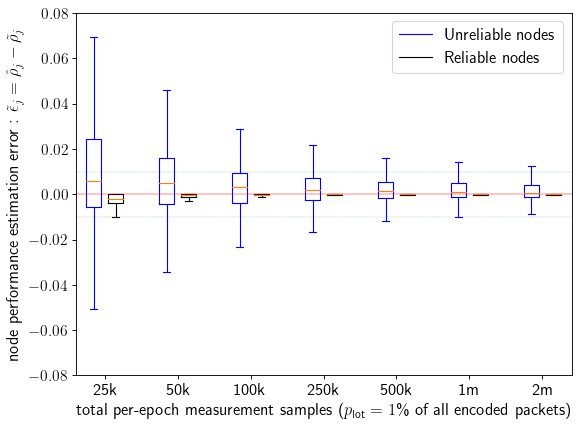

In [15]:
params = {
  "text.usetex": True,
  "text.latex.preamble": [r"\usepackage{amsmath}"]
}
matplotlib.rcParams.update(params)

load = {"_25k": 1,
       "_50k": 3,
        "_100k": 5,
        "_250k": 7, 
        "_500k": 9, 
        "_1m": 11, 
        "_2m": 13
       }

fig = plt.figure(figsize=(8,6), dpi= 80, facecolor='w', edgecolor='k')
ax = fig.add_subplot()
for selected_set in sample_subset: 
    
    bp = ax.boxplot([error_unreliable[type_setup[0]+selected_set], error_reliable[type_setup[0]+selected_set]], 
                    positions = [load[selected_set]-0.3, load[selected_set]+0.3], widths = 0.4, showfliers=False)#True)
        
    setp(bp['boxes'][0], color='blue')
    setp(bp['whiskers'][0], color='blue')
    setp(bp['whiskers'][1], color='blue')
    setp(bp['caps'][0], color='blue')
    setp(bp['caps'][1], color='blue')

#ax.set_ylabel('Distribution of (filter_perf_msm - true_perf_all)', fontsize=12)
ax.set_ylabel(r'node performance estimation error : $\tilde{\epsilon}_j = \hat{\rho}_j - \tilde{\rho}_j$ ', fontsize=15)

ax.set_xticks([1, 3, 5, 7, 9, 11, 13])
ax.set_xticklabels(['25k', '50k', '100k', '250k', '500k', '1m', '2m'], fontsize=15)
ax.axhline(y=0, color='r', linewidth=0.4, linestyle='-')
ax.axhline(y=0.01, color='g', linewidth=0.3, linestyle=':')
ax.axhline(y=-0.01, color='g', linewidth=0.3, linestyle=':')
ax.legend([bp["boxes"][0], bp["boxes"][1]], ["Unreliable nodes", "Reliable nodes"], loc='upper right', fontsize=15)
ax.set_xlabel('total per-epoch measurement samples ($p_\mathsf{lot}=1$\% of all encoded packets)', fontsize=15)
plt.ylim((-0.08, 0.08))

ax.tick_params(axis='y', which='major', labelsize=14)

plt.show()


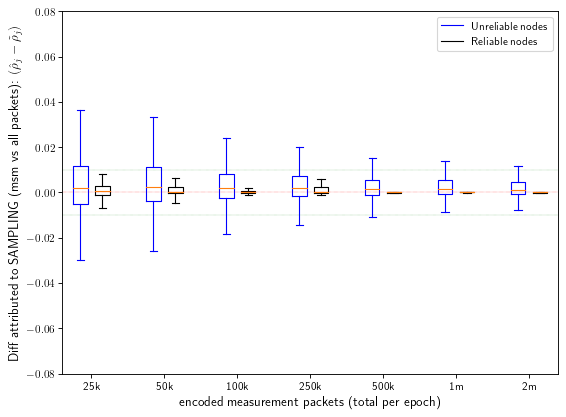

In [17]:

fig = plt.figure(figsize=(8,6), dpi= 80, facecolor='w', edgecolor='k')
ax = fig.add_subplot()
for selected_set in sample_subset: 
    
    bp = ax.boxplot([sampling_error_unreliable[type_setup[0]+selected_set], sampling_error_reliable[type_setup[0]+selected_set]], 
                    positions = [load[selected_set]-0.3, load[selected_set]+0.3], widths = 0.4, showfliers=False)
        
    setp(bp['boxes'][0], color='blue')
    setp(bp['whiskers'][0], color='blue')
    setp(bp['whiskers'][1], color='blue')
    setp(bp['caps'][0], color='blue')
    setp(bp['caps'][1], color='blue')

#ax.set_ylabel('Distribution of (filter_perf_msm - filter_perf_all)', fontsize=12)

ax.set_ylabel(r'Diff attributed to SAMPLING (msm vs all packets): $(\hat{\rho}_j - \tilde{\rho}_{j})$', fontsize=12)
ax.set_xlabel('encoded measurement packets (total per epoch)', fontsize=12)
ax.set_xticks([1, 3, 5, 7, 9, 11, 13])
ax.set_xticklabels(['25k', '50k', '100k', '250k', '500k', '1m', '2m'])

ax.axhline(y=0, color='r', linewidth=0.4, linestyle=':')
ax.axhline(y=0.01, color='g', linewidth=0.3, linestyle=':')
ax.axhline(y=-0.01, color='g', linewidth=0.3, linestyle=':')
ax.legend([bp["boxes"][0], bp["boxes"][1]], ["Unreliable nodes", "Reliable nodes"], loc='upper right')
plt.ylim((-0.08, 0.08))

plt.show()


In [18]:
true_performance = []
estimated_performance = []

setup = "40r40u*"
selected_set = "_2m"

for file_name_nodes in dict_files_nodes[setup+selected_set]:
    for node_id in range(320):            
        true_perf_all = dict_all_nodes[file_name_nodes][str(node_id)]['true_perf_all'] 
        true_perf_msm = dict_all_nodes[file_name_nodes][str(node_id)]['true_perf_msm'] 
        filter_perf_msm = dict_all_nodes[file_name_nodes][str(node_id)]['filter_perf_msm']
        filter_perf_all = dict_all_nodes[file_name_nodes][str(node_id)]['filter_perf_all']
        
        if true_perf_msm < 1:
            true_performance.append(true_perf_all)
            estimated_performance.append(filter_perf_msm)
                                



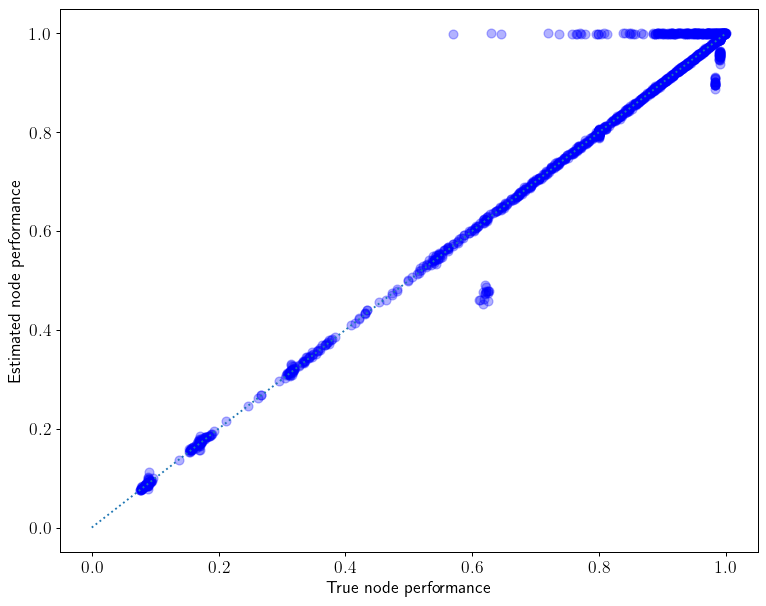

In [19]:
fig = plt.figure(figsize=(10, 8), dpi=90, facecolor='w', edgecolor='k')
ax = fig.add_subplot()

plt.scatter(true_performance, estimated_performance, s=50, color="blue", alpha=0.3)


max_val = 1
ax.plot([0, max_val], [0, max_val], ls=":")
#ax.set(xlim=(-0.002, max_val), ylim=(-0.002, max_val))

ax.set_xlabel("True node performance", fontsize=14)
ax.set_ylabel("Estimated node performance", fontsize=14)
plt.setp(ax.get_yticklabels(), fontsize=14)
plt.setp(ax.get_xticklabels(), fontsize=14)
plt.show()

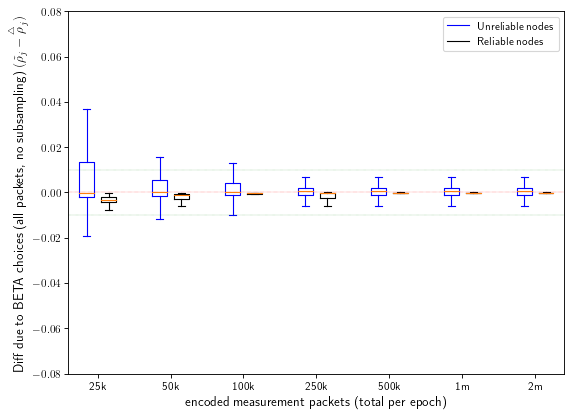

In [10]:

fig = plt.figure(figsize=(8,6), dpi= 80, facecolor='w', edgecolor='k')
ax = fig.add_subplot()
for selected_set in sample_subset: 
    
    bp = ax.boxplot([beta_error_unreliable[type_setup[0]+selected_set], beta_error_reliable[type_setup[0]+selected_set]], 
                    positions = [load[selected_set]-0.3, load[selected_set]+0.3], widths = 0.4, showfliers=False)
        
    setp(bp['boxes'][0], color='blue')
    setp(bp['whiskers'][0], color='blue')
    setp(bp['whiskers'][1], color='blue')
    setp(bp['caps'][0], color='blue')
    setp(bp['caps'][1], color='blue')

params = {
  "text.usetex": True,
  "text.latex.preamble": [r"\usepackage{amsmath}"]
}

ax.set_ylabel(r'Diff due to BETA choices (all packets, no subsampling) $(\tilde{\rho}_j - \overset{\triangle}{\rho}_j)$ ', fontsize=12)
ax.set_xlabel('encoded measurement packets (total per epoch)', fontsize=12)
ax.set_xticks([1, 3, 5, 7, 9, 11, 13])
ax.set_xticklabels(['25k', '50k', '100k', '250k', '500k', '1m', '2m'])

ax.axhline(y=0, color='r', linewidth=0.4, linestyle=':')
ax.axhline(y=0.01, color='g', linewidth=0.3, linestyle=':')
ax.axhline(y=-0.01, color='g', linewidth=0.3, linestyle=':')
ax.legend([bp["boxes"][0], bp["boxes"][1]], ["Unreliable nodes", "Reliable nodes"], loc='upper right')
plt.ylim((-0.08, 0.08))

plt.show()


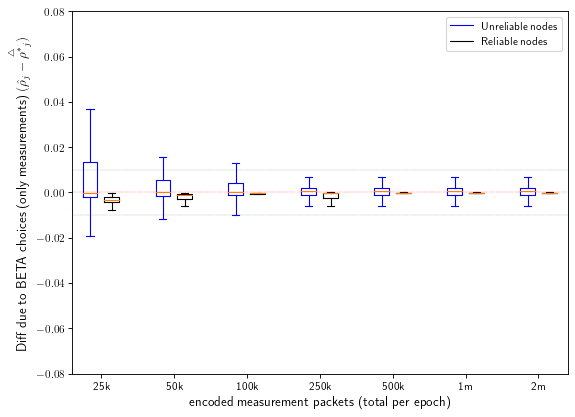

In [228]:
fig = plt.figure(figsize=(8,6), dpi= 80, facecolor='w', edgecolor='k')
ax = fig.add_subplot()
for selected_set in sample_subset: 
    
    bp = ax.boxplot([beta_error_unreliable[type_setup[0]+selected_set], beta_error_reliable[type_setup[0]+selected_set]], 
                    positions = [load[selected_set]-0.3, load[selected_set]+0.3], widths = 0.4, showfliers=False)
        
    setp(bp['boxes'][0], color='blue')
    setp(bp['whiskers'][0], color='blue')
    setp(bp['whiskers'][1], color='blue')
    setp(bp['caps'][0], color='blue')
    setp(bp['caps'][1], color='blue')

params = {
  "text.usetex": True,
  "text.latex.preamble": [r"\usepackage{amsmath}"]
}

ax.set_ylabel(r'Diff due to BETA choices (only measurements) $(\hat{\rho}_j - \overset{\triangle}{\rho^*}_j)$ ', fontsize=12)
ax.set_xlabel('encoded measurement packets (total per epoch)', fontsize=12)
ax.set_xticks([1, 3, 5, 7, 9, 11, 13])
ax.set_xticklabels(['25k', '50k', '100k', '250k', '500k', '1m', '2m'])

ax.axhline(y=0, color='r', linewidth=0.4, linestyle=':')
ax.axhline(y=0.01, color='g', linewidth=0.3, linestyle=':')
ax.axhline(y=-0.01, color='g', linewidth=0.3, linestyle=':')
ax.legend([bp["boxes"][0], bp["boxes"][1]], ["Unreliable nodes", "Reliable nodes"], loc='upper right')
plt.ylim((-0.08, 0.08))

plt.show()



In [89]:
setup = "40r40u*"
selected_set = "_1m"
sequence_containing_x_vals = []
sequence_containing_y_vals = []

for file_name_nodes in dict_files_nodes[setup+selected_set]:
    for node_id in range(320):
        true_perf_all = dict_all_nodes[file_name_nodes][str(node_id)]['true_perf_all'] 
        true_perf_msm = dict_all_nodes[file_name_nodes][str(node_id)]['true_perf_msm'] 
        filter_perf_msm = dict_all_nodes[file_name_nodes][str(node_id)]['filter_perf_msm']
        filter_perf_all = dict_all_nodes[file_name_nodes][str(node_id)]['filter_perf_all']
        
        if true_perf_all < 1:
            val_y = filter_perf_msm
            val_x = true_perf_msm
            sequence_containing_x_vals.append(val_x)
            sequence_containing_y_vals.append(val_y)



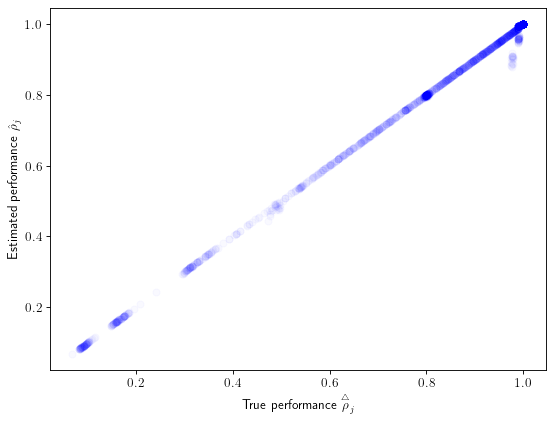

In [82]:
fig = plt.figure(figsize=(8,6), dpi= 80, facecolor='w', edgecolor='k')
ax = fig.add_subplot()

plt.scatter(sequence_containing_x_vals, sequence_containing_y_vals, s=40, color="blue", alpha=0.025)
    
params = {
  "text.usetex": True,
  "text.latex.preamble": [r"\usepackage{amsmath}"]
}
ax.set_ylabel(r'Estimated performance $\hat{\rho}_j$ ', fontsize=12)
ax.set_xlabel(r'True performance $\overset{\triangle}{\rho}_j$ ', fontsize=12)
plt.setp(ax.get_yticklabels(), fontsize=12)
plt.setp(ax.get_xticklabels(), fontsize=12)
plt.show()


In [69]:
error_samples = {}
error_reliable = {}
error_unreliable = {}


for setup in type_setup:
    for selected_set in sample_subset: 
        
        error_samples[setup+selected_set] = []
        error_reliable[setup+selected_set] = []
        error_unreliable[setup+selected_set] = []

        for file_name_nodes in dict_files_nodes[setup+selected_set]:
            for node_id in range(320):    
                true_perf = dict_all_nodes[file_name_nodes][str(node_id)]['true_perf_all'] 
                filter_perf_msm = dict_all_nodes[file_name_nodes][str(node_id)]['filter_perf_msm']
                filter_perf_all = dict_all_nodes[file_name_nodes][str(node_id)]['filter_perf_all']
                                
                error_node = abs(true_perf - filter_perf_msm)
                error_samples[setup+selected_set].append(error_node)

                if node_id < 40 or 79 < node_id < 120 or 159 < node_id < 200 or 239 < node_id < 280:
                    node_reliable = 1
                else:
                    node_reliable = 0
                
                if node_reliable == 0:
                    error_unreliable[setup+selected_set].append(error_node)
                    #error_unreliable[setup+selected_set].append(0)
                else:
                    error_reliable[setup+selected_set].append(error_node)
                 

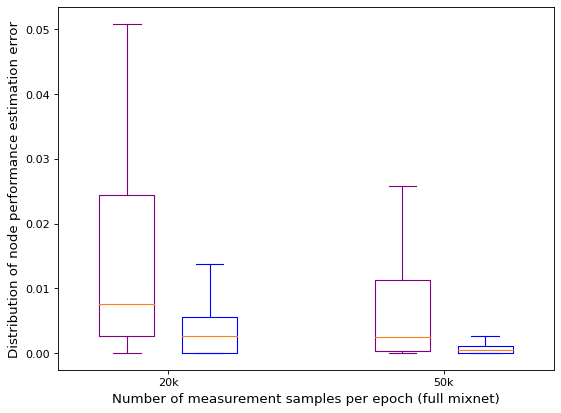

320
160
160
[5.485463521670564e-05, 0.0021645021645021467, 0.0, 0.0, 0.003296703296703285, 0.0010504201680672232, 0.0011655011655011815, 0.0, 0.0, 0.0, 0.0029354207436399493, 0.0020661157024793875, 0.0, 0.00222717149220486, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0022026431718061845, 0.0010869565217391797, 0.0, 0.0, 0.0, 0.0010373443983402453, 0.0009940357852882276, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0021739130434782483, 0.0022321428571429047, 0.0, 0.0010548523206751481, 0.001098901098901095, 0.0023419203747072626, 0.0, 0.0, 0.0, 0.0010570824524313016, 0.0015608740894901274, 0.0, 0.0010834236186348933, 0.002123142250530785, 0.0005464480874316502, 0.0005376344086021057, 0.0005605381165919576, 0.0015075376884422509, 0.003225806451612856, 0.0, 0.002572016460905324, 0.0010752688172043223, 0.00455927051671734, 0.0005500550055005382, 0.0026680896478121774, 0.0010362694300518616, 0.0015544041450776813, 0.0011173184357542443, 0.0, 0.0010224948875255935, 0.0010537407797681642, 0.0020876826722338038, 0.00104058

In [70]:
load = {"20k": 1,
       "50k": 3
       }
         

fig = plt.figure(figsize=(8,6), dpi= 80, facecolor='w', edgecolor='k')
ax = fig.add_subplot()
for selected_set in sample_subset: 
    bp = ax.boxplot([error_unreliable[type_setup[0]+selected_set], error_reliable[type_setup[0]+selected_set]], 
                    positions = [load[selected_set]-0.3, load[selected_set]+0.3], widths = 0.4, showfliers=False)
    
        
    setp(bp['boxes'][0], color='purple')
    setp(bp['whiskers'][0], color='purple')
    setp(bp['whiskers'][1], color='purple')
    setp(bp['caps'][0], color='purple')
    setp(bp['caps'][1], color='purple')

    setp(bp['boxes'][1], color='blue')
    setp(bp['whiskers'][2], color='blue')
    setp(bp['whiskers'][3], color='blue')
    setp(bp['caps'][2], color='blue')
    setp(bp['caps'][3], color='blue')

ax.set_ylabel('Distribution of node performance estimation error', fontsize=12)
ax.set_xlabel('Number of measurement samples per epoch (full mixnet)', fontsize=12)
#ax.set_xticks([1, 3, 5, 7])
#ax.set_xticklabels(['20k', '50k', '200k', '500k'])
ax.set_xticks([1, 3])
ax.set_xticklabels(['20k', '50k'])
#ax.set(ylim=(-0.0002, 0.0102))
plt.show()

print(len(error_samples[type_setup[0]+selected_set]))
print(len(error_reliable[type_setup[0]+selected_set]))
print(len(error_unreliable[type_setup[0]+selected_set]))

print(str(error_reliable[type_setup[0]+selected_set]))

In [77]:
error_samples = {}
error_reliable = {}
error_unreliable = {}


for setup in type_setup:
    for selected_set in sample_subset: 
        error_samples[setup+selected_set] = []
        error_reliable[setup+selected_set] = []
        error_unreliable[setup+selected_set] = []

        for file_name_nodes in dict_files_nodes[setup+selected_set]:
            for node_id in range(320):    
                true_perf = dict_all_nodes[file_name_nodes][str(node_id)]['true_perf_all'] 
                filter_perf_msm = dict_all_nodes[file_name_nodes][str(node_id)]['filter_perf_msm']
                filter_perf_all = dict_all_nodes[file_name_nodes][str(node_id)]['filter_perf_all']
                                
                #error_node = abs(true_perf - filter_perf_msm)
                error_node = abs(filter_perf_all - filter_perf_msm)

                error_samples[setup+selected_set].append(error_node)

                if node_id < 40 or 79 < node_id < 120 or 159 < node_id < 200 or 239 < node_id < 280:
                    node_reliable = 1
                else:
                    node_reliable = 0
                
                if node_reliable == 0:
                    error_unreliable[setup+selected_set].append(error_node)
                    #error_unreliable[setup+selected_set].append(0)
                else:
                    error_reliable[setup+selected_set].append(error_node)

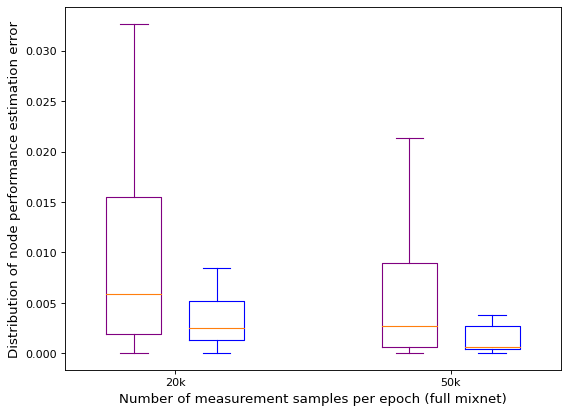

320
160
160
[0.0, 0.0017296763433025664, 0.00047113667923026625, 0.0004507564062982139, 0.002888883034215306, 0.0006260831945882339, 0.0006769481482225004, 0.0004088358090612587, 0.0004283107176997758, 0.0004018099995054536, 0.002601291274658357, 0.0016654055207419027, 0.0004470716804927388, 0.0017737947671996324, 0.0004762081462515999, 0.0005079663998810435, 0.0003706403429658556, 0.0004270489063834537, 0.0003952178638474413, 0.0018053842583093394, 0.0006758440264109655, 0.00042073480095528026, 0.0004376178794640584, 0.0004507564062982139, 0.000613499376026061, 0.0006525396597170108, 0.0004972464975200319, 0.00040032518722898924, 0.00043997719554822456, 0.00043444800278047424, 0.0004035712955259285, 0.0003481807555522076, 0.0018509838270783785, 0.0018294765869476537, 0.00035945363048162093, 0.0006586509017788567, 0.0007192409258756083, 0.0019423050045010992, 0.0003931847968545732, 0.0004635638791025132, 0.001378959204022312, 0.0004118344090187076, 0.00019812815643505122, 0.00145780322

In [78]:
load = {"20k": 1,
       "50k": 3
       }
         

fig = plt.figure(figsize=(8,6), dpi= 80, facecolor='w', edgecolor='k')
ax = fig.add_subplot()
for selected_set in sample_subset: 
    bp = ax.boxplot([error_unreliable[type_setup[0]+selected_set], error_reliable[type_setup[0]+selected_set]], 
                    positions = [load[selected_set]-0.3, load[selected_set]+0.3], widths = 0.4, showfliers=False)
    
        
    setp(bp['boxes'][0], color='purple')
    setp(bp['whiskers'][0], color='purple')
    setp(bp['whiskers'][1], color='purple')
    setp(bp['caps'][0], color='purple')
    setp(bp['caps'][1], color='purple')

    setp(bp['boxes'][1], color='blue')
    setp(bp['whiskers'][2], color='blue')
    setp(bp['whiskers'][3], color='blue')
    setp(bp['caps'][2], color='blue')
    setp(bp['caps'][3], color='blue')

ax.set_ylabel('Distribution of node performance estimation error', fontsize=12)
ax.set_xlabel('Number of measurement samples per epoch (full mixnet)', fontsize=12)
#ax.set_xticks([1, 3, 5, 7])
#ax.set_xticklabels(['20k', '50k', '200k', '500k'])
ax.set_xticks([1, 3])
ax.set_xticklabels(['20k', '50k'])
#ax.set(ylim=(-0.0002, 0.0102))
plt.show()

print(len(error_samples[type_setup[0]+selected_set]))
print(len(error_reliable[type_setup[0]+selected_set]))
print(len(error_unreliable[type_setup[0]+selected_set]))

print(str(error_reliable[type_setup[0]+selected_set]))

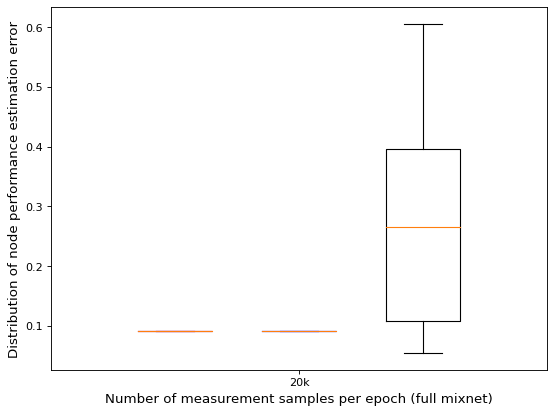

320
275
45
[0.09161490683229812, 0.09161490683229812, 0.09161490683229812, 0.09161490683229812, 0.09161490683229812, 0.09161490683229812, 0.09161490683229812, 0.09161490683229812, 0.09161490683229812, 0.09161490683229812, 0.09161490683229812, 0.09161490683229812, 0.09161490683229812, 0.09161490683229812, 0.09161490683229812, 0.09161490683229812, 0.09161490683229812, 0.09161490683229812, 0.09161490683229812, 0.09161490683229812, 0.09161490683229812, 0.09161490683229812, 0.09161490683229812, 0.09161490683229812, 0.09161490683229812, 0.09161490683229812, 0.09161490683229812, 0.09161490683229812, 0.09161490683229812, 0.09161490683229812, 0.09161490683229812, 0.09161490683229812, 0.09161490683229812, 0.09161490683229812, 0.09161490683229812, 0.09161490683229812, 0.09161490683229812, 0.09161490683229812, 0.09161490683229812, 0.2184014559540507, 0.09161490683229812, 0.09161490683229812, 0.09161490683229812, 0.09161490683229812, 0.08620573971750356, 0.09161490683229812, 0.0737994582476188, 0.0

In [45]:
load = {"20k": 1}

fig = plt.figure(figsize=(8,6), dpi= 80, facecolor='w', edgecolor='k')
ax = fig.add_subplot()
for selected_set in sample_subset: 
    bp = ax.boxplot([error_samples[type_setup[0]+selected_set], error_reliable[type_setup[0]+selected_set], error_unreliable[type_setup[0]+selected_set]], 
                    positions = [load[selected_set]-0.5, load[selected_set], load[selected_set]+0.5], widths = 0.3, showfliers=False)
    setp(bp['boxes'][0], color='purple')
    setp(bp['whiskers'][0], color='purple')
    setp(bp['whiskers'][1], color='purple')
    setp(bp['caps'][0], color='purple')
    setp(bp['caps'][1], color='purple')

    setp(bp['boxes'][1], color='blue')
    setp(bp['whiskers'][2], color='blue')
    setp(bp['whiskers'][3], color='blue')
    setp(bp['caps'][2], color='blue')
    setp(bp['caps'][3], color='blue')

ax.set_ylabel('Distribution of node performance estimation error', fontsize=12)
ax.set_xlabel('Number of measurement samples per epoch (full mixnet)', fontsize=12)
#ax.set_xticks([1, 3, 5, 7])
#ax.set_xticklabels(['20k', '50k', '200k', '500k'])
ax.set_xticks([1])
ax.set_xticklabels(['20k'])
#ax.set(ylim=(-0.0002, 0.0102))
plt.show()

print(len(error_samples[type_setup[0]+selected_set]))
print(len(error_reliable[type_setup[0]+selected_set]))
print(len(error_unreliable[type_setup[0]+selected_set]))

print(str(error_reliable[type_setup[0]+selected_set]))

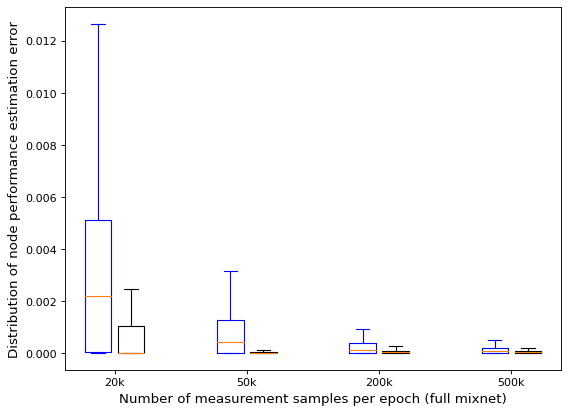

1600


In [8]:
load = {"20k": 1, 
        "50k": 3, 
        "200k": 5, 
        "500k": 7}

fig = plt.figure(figsize=(8,6), dpi= 80, facecolor='w', edgecolor='k')
ax = fig.add_subplot()
for selected_set in sample_subset: 
    #bp = ax.boxplot([error_samples[selected_set], performance_nodes_in_msm[node_id][load]], positions = [load, load+0.5], widths = 0.4)
    bp = ax.boxplot([error_samples[type_setup[1]+selected_set],error_samples[type_setup[2]+selected_set]], positions = [load[selected_set], load[selected_set]+0.5], widths = 0.4, showfliers=False)
    setp(bp['boxes'][0], color='blue')
    setp(bp['whiskers'][0], color='blue')
    setp(bp['whiskers'][1], color='blue')
    setp(bp['caps'][0], color='blue')
    setp(bp['caps'][1], color='blue')

ax.set_ylabel('Distribution of node performance estimation error', fontsize=12)
ax.set_xlabel('Number of measurement samples per epoch (full mixnet)', fontsize=12)
ax.set_xticks([1.25, 3.25, 5.25, 7.25])
ax.set_xticklabels(['20k', '50k', '200k', '500k'])
#ax.set(ylim=(-0.0002, 0.0102))
plt.show()

print(len(error_samples[type_setup[0]+selected_set]))

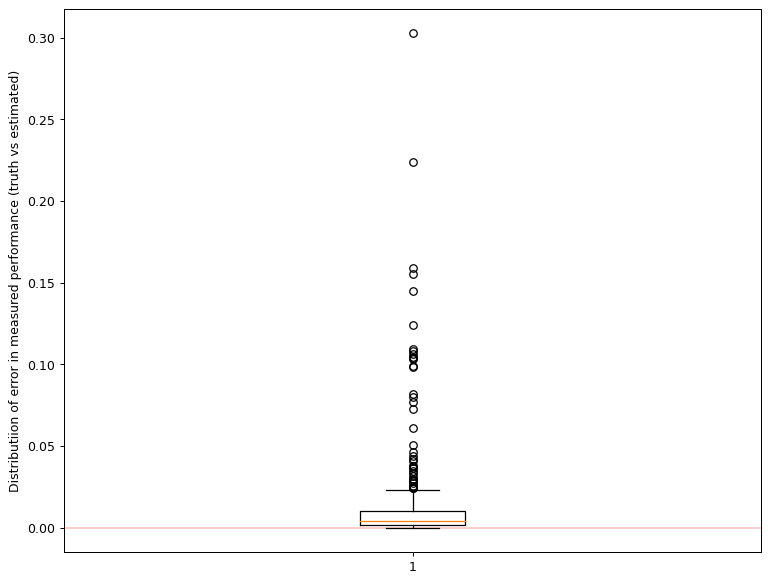

320


In [18]:
fig = plt.figure(figsize=(10,8), dpi= 90, facecolor='w', edgecolor='k')
ax = fig.add_subplot()
ax.axhline(y=0, color='r', linewidth=0.3, linestyle='-')
#ax.boxplot(error_samples["10k"], showfliers=False)
ax.boxplot(error_samples[type_setup[0]+"20k"], showfliers=True)
ax.set_ylabel('Distributiion of error in measured performance (truth vs estimated)')
#ax.set(ylim=(-0.0002, 0.0102))
plt.show()

print(len(error_samples[type_setup[0]+"20k"]))

In [ ]:
load = {"20k": 1, 
        "50k": 3, 
        "200k": 5, 
        "500k": 7}

fig = plt.figure(figsize=(8,6), dpi= 80, facecolor='w', edgecolor='k')
ax = fig.add_subplot()
for selected_set in sample_subset: 
    #bp = ax.boxplot([error_samples[selected_set], performance_nodes_in_msm[node_id][load]], positions = [load, load+0.5], widths = 0.4)
    bp = ax.boxplot([error_samples[type_setup[1]+selected_set],error_samples[type_setup[2]+selected_set]], positions = [load[selected_set], load[selected_set]+0.5], widths = 0.4, showfliers=False)
    setp(bp['boxes'][0], color='blue')
    setp(bp['whiskers'][0], color='blue')
    setp(bp['whiskers'][1], color='blue')
    setp(bp['caps'][0], color='blue')
    setp(bp['caps'][1], color='blue')

ax.set_ylabel('Distribution of node performance estimation error', fontsize=12)
ax.set_xlabel('Number of measurement samples per epoch (full mixnet)', fontsize=12)
ax.set_xticks([1.25, 3.25, 5.25, 7.25])
ax.set_xticklabels(['20k', '50k', '200k', '500k'])
#ax.set(ylim=(-0.0002, 0.0102))
plt.show()

print(len(error_samples[type_setup[0]+selected_set]))

In [ ]:
load = {"20k": 1, 
        "50k": 3, 
        "200k": 5, 
        "500k": 7}

fig = plt.figure(figsize=(8,6), dpi= 80, facecolor='w', edgecolor='k')
ax = fig.add_subplot()
for selected_set in sample_subset: 
    bp = ax.boxplot([error_samples[type_setup[0]+selected_set], error_samples[type_setup[1]+selected_set], error_samples[type_setup[2]+selected_set]], 
                    positions = [load[selected_set]-0.5, load[selected_set], load[selected_set]+0.5], widths = 0.3, showfliers=False)
    setp(bp['boxes'][0], color='purple')
    setp(bp['whiskers'][0], color='purple')
    setp(bp['whiskers'][1], color='purple')
    setp(bp['caps'][0], color='purple')
    setp(bp['caps'][1], color='purple')

    setp(bp['boxes'][2], color='blue')
    setp(bp['whiskers'][2], color='blue')
    setp(bp['whiskers'][3], color='blue')
    setp(bp['caps'][2], color='blue')
    setp(bp['caps'][3], color='blue')

ax.set_ylabel('Distribution of node performance estimation error', fontsize=12)
ax.set_xlabel('Number of measurement samples per epoch (full mixnet)', fontsize=12)
ax.set_xticks([1, 3, 5, 7])
ax.set_xticklabels(['20k', '50k', '200k', '500k'])
#ax.set(ylim=(-0.0002, 0.0102))
plt.show()

print(len(error_samples[type_setup[0]+selected_set]))